### Data Load

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

train_df = pd.read_csv("train.csv")
test_df = pd.read_csv("test.csv")

- 0. 어떤 데이터가 들어있는지 탐색하세요.
- 0. Description Featrure 는 삭제하세요.

In [2]:
train_df.head()

,Type,Age,Breed1,Gender,Color1,Color2,MaturitySize,FurLength,Vaccinated,Sterilized,Health,Fee,Description,PhotoAmt,AdoptionSpeed
0,Dog,2,Mixed Breed,Female,Black,Brown,Medium,Short,No,No,Healthy,0,Mylo is among three siblings found by a friend...,7,2
1,Cat,24,Domestic Medium Hair,Female,Cream,No Color,Medium,Medium,Yes,Yes,Healthy,20,A bit shy and timid..but she is loving and can...,3,1
2,Dog,12,Spitz,Female,White,No Color,Medium,Medium,Not Sure,Not Sure,Healthy,0,Seeking adopters for this sweet girl. She was ...,4,4
3,Dog,12,Pug,Male,Black,Cream,Small,Short,Yes,Yes,Healthy,0,Lucas is a sturdy little dog. Very well behave...,6,3
4,Dog,3,Mixed Breed,Male,Black,No Color,Medium,Short,Not Sure,Not Sure,Healthy,0,"Hi, I'm Randy, few weeks ago I got beaten by h...",2,4


In [3]:
del_Desc = train_df.drop('Description', axis=1, inplace=False)
del_Desc

,Type,Age,Breed1,Gender,Color1,Color2,MaturitySize,FurLength,Vaccinated,Sterilized,Health,Fee,PhotoAmt,AdoptionSpeed
0,Dog,2,Mixed Breed,Female,Black,Brown,Medium,Short,No,No,Healthy,0,7,2
1,Cat,24,Domestic Medium Hair,Female,Cream,No Color,Medium,Medium,Yes,Yes,Healthy,20,3,1
2,Dog,12,Spitz,Female,White,No Color,Medium,Medium,Not Sure,Not Sure,Healthy,0,4,4
3,Dog,12,Pug,Male,Black,Cream,Small,Short,Yes,Yes,Healthy,0,6,3
4,Dog,3,Mixed Breed,Male,Black,No Color,Medium,Short,Not Sure,Not Sure,Healthy,0,2,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10378,Dog,5,Spitz,Male,Black,Brown,Medium,Medium,No,No,Healthy,0,2,3
10379,Dog,3,Jack Russell Terrier,Female,Brown,White,Medium,Short,Yes,No,Healthy,500,1,3
10380,Cat,15,Domestic Short Hair,Male,Yellow,White,Large,Short,Yes,Yes,Healthy,0,2,1
10381,Cat,4,Domestic Short Hair,Male,Gray,No Color,Small,Medium,No,No,Healthy,0,2,4


### Data EDA

- 1. Print Data shape 
- 2. 데이터 정보 infor 를 보고 데이터를 파악하세요.

결측치 유무, 수치형/범주형 데이터 파악하고 markdown을 이용해서아래에 결과 summary 하세요.

In [4]:
print(del_Desc.shape)
del_Desc.info()
del_Desc.isna().sum()

(10383, 14)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10383 entries, 0 to 10382
Data columns (total 14 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Type           10383 non-null  object
 1   Age            10383 non-null  int64 
 2   Breed1         10383 non-null  object
 3   Gender         10383 non-null  object
 4   Color1         10383 non-null  object
 5   Color2         10383 non-null  object
 6   MaturitySize   10383 non-null  object
 7   FurLength      10383 non-null  object
 8   Vaccinated     10383 non-null  object
 9   Sterilized     10383 non-null  object
 10  Health         10383 non-null  object
 11  Fee            10383 non-null  int64 
 12  PhotoAmt       10383 non-null  int64 
 13  AdoptionSpeed  10383 non-null  int64 
dtypes: int64(4), object(10)
memory usage: 1.1+ MB


Type             0
Age              0
Breed1           0
Gender           0
Color1           0
Color2           0
MaturitySize     0
FurLength        0
Vaccinated       0
Sterilized       0
Health           0
Fee              0
PhotoAmt         0
AdoptionSpeed    0
dtype: int64

##### 결측치 - 없음
##### 수치형 데이터 - Age, Fee, PhotoAmt, AdoptionSpeed
##### 범주형 데이터 - Breed1, Gender, Color1, Color2, MaturitySize, FurLength, Vaccinated, Sterilized, Health

- 3. 수치형 변수 | 범주형 변수를 나누세요. 

In [15]:
TARGET = "AdoptionSpeed"
feature_cols = [c for c in train_df.columns if c != TARGET]

num_cols = train_df[feature_cols].select_dtypes(include=["number"]).columns.tolist()
obj_cols = train_df.select_dtypes(include=["object"]).columns.tolist()

print(num_cols)
print(obj_cols)

['Age', 'Fee', 'PhotoAmt']
['Type', 'Breed1', 'Gender', 'Color1', 'Color2', 'MaturitySize', 'FurLength', 'Vaccinated', 'Sterilized', 'Health', 'Description']


In [6]:
obj_cols = del_Desc.select_dtypes(include=["object"])
obj_cols

,Type,Breed1,Gender,Color1,Color2,MaturitySize,FurLength,Vaccinated,Sterilized,Health
0,Dog,Mixed Breed,Female,Black,Brown,Medium,Short,No,No,Healthy
1,Cat,Domestic Medium Hair,Female,Cream,No Color,Medium,Medium,Yes,Yes,Healthy
2,Dog,Spitz,Female,White,No Color,Medium,Medium,Not Sure,Not Sure,Healthy
3,Dog,Pug,Male,Black,Cream,Small,Short,Yes,Yes,Healthy
4,Dog,Mixed Breed,Male,Black,No Color,Medium,Short,Not Sure,Not Sure,Healthy
...,...,...,...,...,...,...,...,...,...,...
10378,Dog,Spitz,Male,Black,Brown,Medium,Medium,No,No,Healthy
10379,Dog,Jack Russell Terrier,Female,Brown,White,Medium,Short,Yes,No,Healthy
10380,Cat,Domestic Short Hair,Male,Yellow,White,Large,Short,Yes,Yes,Healthy
10381,Cat,Domestic Short Hair,Male,Gray,No Color,Small,Medium,No,No,Healthy


- 4. 수치형 변수를 시각화하고 각 데이터에 대해 전처리 방법을 고안해보세요. (적용할 것이 없으면 넘어감)

NameError: name 'sns' is not defined

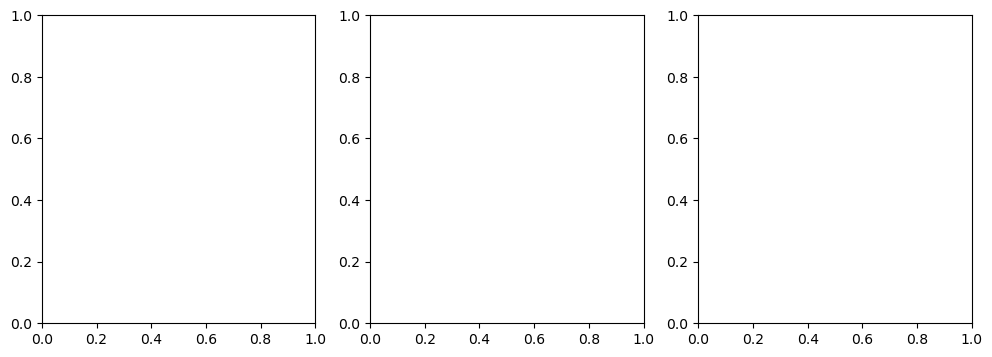

In [7]:
fig, axes = plt.subplots(1, len(num_cols), figsize=(4 * len(num_cols), 4))
if len(num_cols) == 1:
    axes = [axes]
for ax, col in zip(axes, num_cols):
    sns.histplot(train_df[col], kde=True, ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

- 5. 클래스 분포 시각화하고 데이터 분석에 있어서 우려되는 점을 기술하세요.
--------------------------------
- 5. Visualize the class distribution and describe any concerns for data analysis.

- 6. 범주형 변수 분포를 시각화하고 전처리 방법은 고안해보세요. (적용할 것이 없으면 넘어감)
- 7. 범주형 변수처리에 있어 Label encoding, onehot encoding 방식이 있다. 아래 내용을 고민해보세요.

    - Label encoding을 적용할 경우 어울리는 모델은?
    - Label encoding을 적용할 경우 우려되는 점은?
    - Onehot encoding을 해야되는 모델은?
    - Breed1 는 어떻게 처리하면 좋을지 고민하세요.

--------------------------------------------------
- 6. Visualize the distribution of categorical variables and consider appropriate preprocessing methods. If no preprocessing is needed, you may skip it.
- 7. There are two common methods for handling categorical variables: Label Encoding and One-Hot Encoding. Consider the following questions:
    - Which models are suitable when Label Encoding is applied?
    - What concerns may arise when Label Encoding is applied?
    - Which models require One-Hot Encoding?
    - Consider how Breed1 should be handled.

- 8. 위 인코딩 전략을 적용하여 실제로 인코딩을 진행하세요.
--------------------------------
- 8. Apply the encoding strategy above and actually perform the encoding.

### Feature Selection

- 9. Correlation 분석을 실시하고 feature selection 진행하세요.
- 10. Mutual Information 이 무엇인지 파악하세요. Correlation과 차이점을 파악하세요.
- 11. 9번에 이어서 Mutual Information 기반의 feature selection 진행하세요. (시각화도 하세요.)
-----------------------------------
- 9. Conduct correlation analysis and perform feature selection.
- 10. Understand what Mutual Information is and identify the differences between Mutual Information and Correlation.
- 11. Following Question 9, perform feature selection based on Mutual Information. Also visualize the results.

### Modeling

- 12. 위 학습 전략을 적용하여 전체 데이터 처리 파이프라인 만들고 데이터 정제하기
- 13. 학습을 위해 Train test split 을 이용해 데이터 8:2로 나누기
--------------------------------
- 12. Build a complete data preprocessing pipeline based on the strategies above and clean the dataset.
- 13. Split the data into training and test sets using an 8:2 ratio with train_test_split.

- 14. 적절한 모델 3가지 이상을 설정하고 학습하기 (모델 선택 이유는?)
--------------------------------
- 14. Select and train at least three appropriate models. Explain why you selected those models.

### Evaluation

- 15. 모델 평가 메트릭을 정하고 평가하기, 평가결과 분석하기 (시각화 필수)
- 16. Class weight / Optuna 적용해서 최적화하기
--------------------------------
- 15. Choose suitable model evaluation metrics, evaluate the models, and analyze the evaluation results. Visualization is required.
- 16. Apply class_weight and/or Optuna to optimize the model.

### Interpretation with SHAP

- 17. shap을 이용해 결과 분석하기
    - 입양 속도에 영향을 미치는 중요한 인자는?
    - 해당인자가 어떤 값을 가질 때 입양속도가 빨라지는가?
    - 통제 가능한 변수는 무엇이고 어떻게 활용 하면 좋은가?
--------------------------------
- 17. Analyze the results using SHAP.
    - What are the important factors that affect adoption speed?
    - When those factors have certain values, does the adoption speed become faster?
    - What are the controllable variables, and how can they be effectively utilized?